# 실습 1

- cust 데이터의 이상치를 제거하고
- 나이는 5단위로 범주화
- 평균 요금은 5개 구간으로 나누어
- 새로운 변수에 데이터를 저장하라.

- 이상치 처리 대상 컬럼: avg_bill, A_bill, B_bill
- 나이 범주화: 0~4세는 0, 5~9세는 5, 10~14세는 10으로 범주화(5단위), by_age 컬럼에 저장
- 평균 요금 범주화: 균등비율로 low, lowmid, mid, midhigh, high 5개 구간으로 범주화, bill_rating 컬럼에 저장

In [1]:
import pandas as pd
import numpy as np

cust = pd.read_csv('../cust_data.csv')
cust_fix = cust.copy()

cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.000000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.000000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.710010,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.000000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.999900,0.0000,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y


In [10]:
cust = cust_fix.copy()

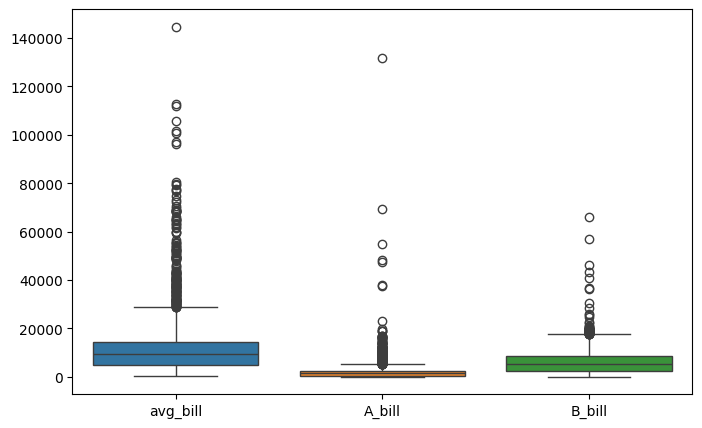

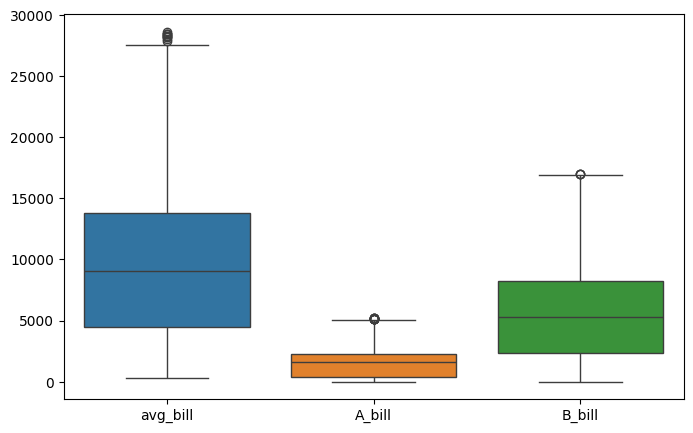

In [11]:
# 1. 이상치 제거

# 이상치 유무 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=cust[['avg_bill', 'A_bill', 'B_bill']])
plt.show()

# 이상치 제거 함수 만들기
def removeOutlier(df, column):
    # Q1, Q3
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    # IQR
    iqr = q3 - q1

    # 이상치 제거 (정상치만 수집)
    isRemoveOutlier = (df[column] < (q3 + 1.5*iqr)) & (df[column] > (q1 - 1.5*iqr))
    y = df[isRemoveOutlier]

    return y

# 이상치 제거 함수 사용
cust = removeOutlier(cust, 'avg_bill')
cust = removeOutlier(cust, 'A_bill')
cust = removeOutlier(cust, 'B_bill')

# 제거 결과 확인
plt.figure(figsize=(8,5))
sns.boxplot(data=cust[['avg_bill', 'A_bill', 'B_bill']])
plt.show()

In [13]:
# 2. 나이 범주화
    # 연속형 데이터를 범주형 데이터로 범주화
    # 범주화 공식 = (x // 단위) * 단위
    # by_age 컬럼에 저장
cust['by_age'] = (cust['age'] // 5) * 5
cust = cust.astype({ 'age':int, 'by_age':int }) # 나이이므로 정수형으로 변경
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,Y,25
1,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,N,20
2,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,N,30
3,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,N,15
4,C,F,78,1,N,N,1361.7999,1173.99990,0.0000,N,75


In [14]:
# 3. 평균 요금 범주화
    # cut, qcut 중 균등비율 구분해야 하므로 qcut
    # low / lowmid / mid / midhigh / high로 5단계로 구분
    # bill_rating 컬럼에 저장
cust['bill_rating'] = pd.qcut(cust['avg_bill'], 5, labels=['low', 'lowmid', 'mid', 'midhigh', 'high'])
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age,bill_rating
0,C,F,28,0,N,N,2640.0000,792.000000,1584.0000,Y,25,low
1,E,F,24,1,N,N,16840.0000,2526.000000,6983.0000,N,20,high
2,F,F,32,1,N,N,15544.7334,2331.710010,6750.4666,N,30,high
3,D,M,18,1,N,N,4700.0000,0.000000,4502.0000,N,15,lowmid
4,C,F,78,1,N,N,1361.7999,1173.999900,0.0000,N,75,low
...,...,...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76,1,N,N,1860.0000,1716.000000,0.0000,N,75,low
8224,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,N,15,low
8225,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,N,10,midhigh
8226,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,Y,40,low


# 실습 2

- npay 칼럼에 Label Encoding 수행하고,
- termination 컬럼에 One-Hot Encoding 수행하고,
- cust 데이터프레임에 결측치가 있는지 확인하고,
- 전처리 결과를 cust_data.csv 파일로 저장하라.

In [17]:
import pandas as pd
import numpy as np

cust = pd.read_csv('../cust_data.csv')
cust_fix = cust.copy()

cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.000000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.000000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.710010,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.000000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.999900,0.0000,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y


In [41]:
cust = cust_fix.copy()

In [42]:
# 1. npay 칼럼에 Label Encoding 수행
    # replace 함수 사용
# cust = cust['npay'].replace({ 'N':0, 'Y':1 })
    # (추천) sklearn.preprocessing의 LabelEncoder 사용, fit_transform
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cust['npay'] = le.fit_transform(cust['npay'])
cust # 결과 확인

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.000000,1584.0000,Y
1,E,F,24.0,1,N,0,16840.0000,2526.000000,6983.0000,N
2,F,F,32.0,1,N,0,15544.7334,2331.710010,6750.4666,N
3,D,M,18.0,1,N,0,4700.0000,0.000000,4502.0000,N
4,C,F,78.0,1,N,0,1361.7999,1173.999900,0.0000,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.0,1,N,0,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,1,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,0,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,0,3140.0000,942.000000,1884.0000,Y


In [49]:
# 2. termination 컬럼에 One-Hot Encoding 수행
    # pandas의 get_dummies 사용
    # "dtype='int' 옵션 사용"으로 변경해야 (기존 False, True에서) 0, 1로 이뤄진 2차원 행렬로 바뀜
pd.get_dummies(data=cust, columns=['termination'], dtype='int')
    # drop_first=True 옵션 사용: 첫 번째 생성된 컬럼(termination_N)이 삭제됨
pd.get_dummies(data=cust, columns=['termination'], drop_first=True, dtype='int')

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination_Y
0,C,F,28.0,0,N,0,2640.0000,792.000000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.000000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.710010,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.000000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.999900,0.0000,0
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.0,1,N,0,1860.0000,1716.000000,0.0000,0
8224,C,F,15.0,1,N,1,1296.0999,194.414985,643.1001,0
8225,G,M,12.0,1,N,0,13799.6666,2069.949990,10605.9266,0
8226,C,F,40.0,0,N,0,3140.0000,942.000000,1884.0000,1


In [51]:
# cust 데이터프레임에 결측치가 있는지 확인
# cust.isnull().sum()
cust.isna().sum()

class          0
sex            0
age            0
service        0
stop           0
npay           0
avg_bill       0
A_bill         0
B_bill         0
termination    0
dtype: int64

In [52]:
# 전처리 결과를 cust_data.csv 파일로 저장
cust.to_csv('cust_data.csv', index=False)